# 📖Reutilizadas del TP4

## ⏹️Mínimos cudrados (Ajuste completo + descarga de coeficientes)

Función reutilizada del TP4 (Ahora funciona con los puntos de JuanC)

**Entrada:** (cargado desde Drive o subido manualmente)

- Un archivo CSV con contornos (contornos_izq.csv o contornos_der.csv),

- Opcionalmente la respuesta del usuario sobre si guardar coeficientes.

**Salida:** (se guarda en Drive o se descarga a la compu, según el modo)

- Una interfaz interactiva (Plotly + widgets) para navegar frame a frame, ver puntos limpios, spline cúbico y ajuste por mínimos cuadrados.

- Un archivo CSV extra con los coeficientes del polinomio de grado 4 por frame

In [ ]:
# ==== 0) Arranque interactivo: subir archivo o usar Drive (Colab OK) ====
import os, re, numpy as np, pandas as pd
import plotly.graph_objects as go
from plotly.graph_objects import FigureWidget
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
import ipywidgets as W
from IPython.display import display
from google.colab import output
output.enable_custom_widget_manager()

# --- elegir origen ---
eleccion = input("¿Cargar archivo? 1 = subir CSV, 0 = usar Drive: ").strip()

if eleccion == '1':
    # Subir CSV desde tu compu
    from google.colab import files
    print("Elegí el CSV (contornos_izq.csv o contornos_der.csv)")
    up = files.upload()
    assert len(up) == 1, "Subí exactamente un archivo CSV."
    CSV_PATH = list(up.keys())[0]
else:
    # Leer desde Drive en la ruta pedida
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = "/content/drive/MyDrive/Procesados/Contornos separados/"
    lado = input("¿Qué contorno querés? Escribí 'izq' o 'der': ").strip().lower()
    assert lado in ("izq","der"), "Debe ser 'izq' o 'der'."
    CSV_PATH = BASE_DIR + (f"contornos_{lado}.csv")

print(f"Usando archivo: {CSV_PATH}")

# Flag para saber si el archivo fue subido localmente (no Drive)
IS_LOCAL_UPLOAD = (eleccion == '1')

# ==== 2.1) Parámetros del filtro de “meseta” ====
FLOOR_FROM = 17    # a partir de qué frame aplicar el filtro de meseta
SLOPE_TOL  = 1e-3  # pendiente ~0 considerada “meseta”
MIN_RUN    = 12    # cantidad mínima de puntos planos para eliminar
KEEP_FIRST = 1     # conservar algunos puntos iniciales de la meseta (p. ej. el de contacto)

# ---------------- Utilidades de carga ----------------
def _order_key(name: str):
    m = re.search(r"(\d+)$", name)
    return (int(m.group(1)) if m else 1_000_000, name)

def load_contours(csv_path):
    df = pd.read_csv(csv_path, dtype=object)
    bases = []
    for c in df.columns:
        m = re.match(r"(.+)_x$", c)
        if m and f"{m.group(1)}_y" in df.columns:
            bases.append(m.group(1))
    bases = sorted(bases, key=_order_key)

    frames = []
    Xall, Yall = [], []
    for b in bases:
        x = pd.to_numeric(df[f"{b}_x"], errors="coerce").to_numpy()
        y = pd.to_numeric(df[f"{b}_y"], errors="coerce").to_numpy()
        good = ~np.isnan(x) & ~np.isnan(y)
        x = x[good]; y = y[good]
        frames.append({"name": b, "x": x, "y": y})
        if x.size: Xall.append(x)
        if y.size: Yall.append(y)

    xr = (float(np.min(np.concatenate(Xall))) if Xall else -1.0,
          float(np.max(np.concatenate(Xall))) if Xall else  1.0)
    yr = (float(np.min(np.concatenate(Yall))) if Yall else -1.0,
          float(np.max(np.concatenate(Yall))) if Yall else  1.0)
    return frames, xr, yr

frames, xr, yr = load_contours(CSV_PATH)
assert len(frames) > 0, "No se encontraron pares *_x / *_y en el CSV."

# ======= Guardar coeficientes de ajuste por frame (grado 4) =======
# ======= Guardar coeficientes de ajuste por frame (grado 4) =======
# Pregunta al usuario
save_coefs_answer = input("¿Guardar archivo de coeficientes por frame (grado 4)? (s/n): ").strip().lower()
WANT_COEFS = (save_coefs_answer == 's')

# Detectar lado (para nombre del archivo)
_csv_low = CSV_PATH.lower()
if   "izq" in _csv_low: SIDE_FOR_COEFS = "izq"
elif "der" in _csv_low: SIDE_FOR_COEFS = "der"
else:
    SIDE_FOR_COEFS = input("No se detectó lado en el nombre. Escribí 'izq' o 'der': ").strip().lower()
    assert SIDE_FOR_COEFS in ("izq","der"), "Debe ser 'izq' o 'der'."

def _fit_degree4_and_interval(fr, i):
    """
    Usa el MISMO pipeline de limpieza global que la UI (get_clean_xy),
    ajusta y = a x^4 + b x^3 + c x^2 + d x + e por mínimos cuadrados,
    y devuelve (ok, a,b,c,d,e, xmax_usado).
    xmax_usado = último valor de x de los puntos LIMPIOS del frame.
    """
    # datos limpios (globales: ordenar, filtrar meseta, dedup, outliers)
    x, y = get_clean_xy(fr, i)
    if x.size < 6:  # 5 parámetros + 1 mínimo
        xmax = float(x.max()) if x.size else np.nan
        return False, (np.nan, np.nan, np.nan, np.nan, np.nan, xmax)

    # Modelo fijo grado 4 (independiente de los widgets)
    eq = "a*x**4 + b*x**3 + c*x**2 + d*x + e"
    params = ["a","b","c","d","e"]
    p0 = [1.0, 0.0, 0.0, 0.0, 0.0]

    try:
        f = build_model(eq, params)
        popt, _ = curve_fit(f, x, y, p0=p0, maxfev=20000)
        a,b,c,d,e = [float(v) for v in popt]
        xmax = float(np.max(x)) if x.size else np.nan
        return True, (a,b,c,d,e,xmax)
    except Exception:
        xmax = float(np.max(x)) if x.size else np.nan
        return False, (np.nan, np.nan, np.nan, np.nan, np.nan, xmax)

def save_coefficients_degree4(frames, out_path):
    rows = []
    for i, fr in enumerate(frames):
        ok, (a,b,c,d,e,xmax) = _fit_degree4_and_interval(fr, i)
        rows.append({
            "frame": fr["name"],
            "a": a, "b": b, "c": c, "d": d, "e": e,
            "intervalo": xmax  # último x de los puntos usados
        })
    df = pd.DataFrame(rows, dtype=object)
    df.to_csv(out_path, index=False)

def _save_coefs_if_requested():
    """Difiere el guardado hasta que TODO esté definido."""
    if not WANT_COEFS:
        return
    # si fue subida local, guardamos en /content para asegurar permisos y luego descargamos
    out_dir = "/content" if IS_LOCAL_UPLOAD else os.path.dirname(os.path.abspath(CSV_PATH))
    out_name = f"coeficientes_ajuste_{SIDE_FOR_COEFS}.csv"
    out_path = os.path.join(out_dir, out_name)

    save_coefficients_degree4(frames, out_path)
    print(f"Coeficientes (grado 4) guardados en: {out_path}")

    # Si se cargó el CSV desde la compu, inicia descarga a la compu
    if IS_LOCAL_UPLOAD:
        try:
            from google.colab import files as gfiles
            gfiles.download(out_path)
            print("Descargando el archivo de coeficientes a tu computadora…")
        except Exception as e:
            print(f"No pude iniciar la descarga automática: {e}\n"
                  "Podés bajarlo manualmente desde el panel de archivos (ruta /content).")
# ======= /fin bloque coeficientes =======

# ---------------- Spline cúbico paramétrico ----------------
def parametric_cubic_spline(x, y, n_samples=400):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    if x.size < 4: return None, None
    keep = np.ones_like(x, dtype=bool)
    if x.size > 1:
        dx = np.diff(x); dy = np.diff(y)
        keep[1:] = (np.abs(dx) + np.abs(dy)) > 1e-12
    x = x[keep]; y = y[keep]
    if x.size < 4: return None, None
    seg = np.hypot(np.diff(x), np.diff(y))
    t = np.r_[0.0, np.cumsum(seg)]
    L = t[-1]
    if L <= 0: return None, None
    t = t / L
    csx = CubicSpline(t, x, bc_type='natural')
    csy = CubicSpline(t, y, bc_type='natural')
    tt = np.linspace(0, 1, n_samples)
    return csx(tt), csy(tt)

# Precalcular spline de cada frame (si se puede)
for fr in frames:
    xs, ys = parametric_cubic_spline(fr["x"], fr["y"], n_samples=400)
    fr["sx"] = xs
    fr["sy"] = ys
    fr["has_spline"] = xs is not None

# ---------------- Mínimos cuadrados (ecuación libre) ----------------
SAFE_FUNCS = {
    "pi": np.pi, "e": np.e,
    "sin": np.sin, "cos": np.cos, "tan": np.tan,
    "arcsin": np.arcsin, "arccos": np.arccos, "arctan": np.arctan,
    "sinh": np.sinh, "cosh": np.cosh, "tanh": np.tanh,
    "exp": np.exp, "log": np.log, "log10": np.log10,
    "sqrt": np.sqrt, "abs": np.abs, "power": np.power,
    "where": np.where, "clip": np.clip, "sign": np.sign,
    "minimum": np.minimum, "maximum": np.maximum
}
def build_model(eq: str, param_names):
    code = compile(eq, "<user-eq>", "eval")
    def f(x, *theta):
        local = {name: val for name, val in zip(param_names, theta)}
        local["x"] = x
        return eval(code, {"__builtins__": {}}, {**SAFE_FUNCS, **local})
    return f

# ---------------- Preprocesado: ordenar/deduplicar + filtro de meseta ----------------
def sort_and_dedup_x(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    if x.size == 0: return x, y
    idx = np.argsort(x); x, y = x[idx], y[idx]
    xu = np.unique(x)
    y_means = [float(np.mean(y[x==xv])) for xv in xu]
    return xu, np.asarray(y_means)

def drop_flat_runs_by_slope(x, y, slope_tol=SLOPE_TOL, min_run=MIN_RUN, keep_first=KEEP_FIRST):
    x = np.asarray(x, float); y = np.asarray(y, float)
    if x.size < 3: return x, y
    idx = np.argsort(x); x, y = x[idx], y[idx]
    dx = np.diff(x); dy = np.diff(y)
    slope = np.zeros_like(x)
    with np.errstate(divide='ignore', invalid='ignore'):
        slope[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])
        slope[0]    = dy[0] / (dx[0] if dx[0]!=0 else 1e-12)
        slope[-1]   = dy[-1] / (dx[-1] if dx[-1]!=0 else 1e-12)
    flat = np.isfinite(slope) & (np.abs(slope) <= slope_tol)
    keep = np.ones_like(x, bool)
    i, n = 0, len(x)
    while i < n:
        if flat[i]:
            j = i + 1
            while j < n and flat[j]: j += 1
            if (j - i) >= min_run:
                drop_start = i + max(KEEP_FIRST, 0)
                keep[drop_start:j] = False
            i = j
        else:
            i += 1
    return x[keep], y[keep]

def remove_local_outliers(x, y, win=5, n_sigma=3.0):
    x = np.asarray(x, float); y = np.asarray(y, float)
    n = len(y)
    if n == 0 or win < 3:
        return x, y
    if win % 2 == 0:
        win += 1
    half = win // 2
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        i0 = max(0, i - half)
        i1 = min(n, i + half + 1)
        yloc = y[i0:i1]
        med = np.median(yloc)
        mad = np.median(np.abs(yloc - med)) + 1e-9
        if np.abs(y[i] - med) > n_sigma * 1.4826 * mad:
            keep[i] = False
    return x[keep], y[keep]

def get_clean_xy(fr, i):
    """
    1) Ordena por x (sin deduplicar).
    2) Desde FLOOR_FROM elimina la 'meseta' (corridas casi horizontales).
    3) Deduplica por x promediando y.
    4) Elimina outliers locales.
    """
    x0 = np.asarray(fr["x"], float)
    y0 = np.asarray(fr["y"], float)
    if x0.size == 0:
        return x0, y0

    idx = np.argsort(x0)
    x_sorted = x0[idx]
    y_sorted = y0[idx]

    mnum = re.search(r"(\d+)$", fr["name"])
    idx_num = int(mnum.group(1)) if mnum else (i + 1)
    if idx_num >= FLOOR_FROM:
        xf, yf = drop_flat_runs_by_slope(
            x_sorted, y_sorted,
            slope_tol=SLOPE_TOL,
            min_run=MIN_RUN,
            keep_first=KEEP_FIRST
        )
        if len(xf) >= max(10, KEEP_FIRST + 5):
            x_sorted, y_sorted = xf, yf

    xu, yu = sort_and_dedup_x(x_sorted, y_sorted)
    xu, yu = remove_local_outliers(xu, yu, win=5, n_sigma=3.0)
    return xu, yu

# ---------------- FigureWidget + widgets ----------------
N = len(frames)
init_i = next((i for i,f in enumerate(frames) if f["has_spline"]), 0)
f0 = frames[init_i]

x_clean0, y_clean0 = get_clean_xy(f0, init_i)

x0r, x1r = xr; y0r, y1r = yr
dx = x1r - x0r or 1.0
dy = y1r - y0r or 1.0
padx, pady = 0.05*dx, 0.05*dy

fig = FigureWidget(
    data=[
        go.Scatter(x=x_clean0, y=y_clean0, mode="markers", name="puntos", marker=dict(size=6)),
        go.Scatter(x=(f0["sx"] if f0["has_spline"] else []),
                   y=(f0["sy"] if f0["has_spline"] else []),
                   mode="lines", name="spline cúbico (real)", line=dict(width=2, color="red"),
                   visible=True if f0["has_spline"] else False),
        go.Scatter(x=[], y=[], mode="lines", name="LSQ fit", line=dict(width=2, color="green"))
    ],
    layout=go.Layout(
        title=f"Frame {init_i+1}/{N} – {f0['name']}",
        xaxis=dict(title="x", range=[x0r-padx, x1r+padx], zeroline=True, zerolinewidth=1, showgrid=False),
        yaxis=dict(title="y", range=[y0r-pady, y1r+pady], zeroline=True, zerolinewidth=1, showgrid=False),
        margin=dict(t=92, r=20, b=60, l=60),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        height=540, width=900,
        uirevision=True
    )
)

# Navegación
slider = W.IntSlider(value=init_i, min=0, max=N-1, step=1, description='Frame:', continuous_update=False, layout=W.Layout(width="520px"))
play   = W.Play(interval=80, value=init_i, min=0, max=N-1, step=1, description="Play")
W.jslink((play, 'value'), (slider, 'value'))
dd = W.Dropdown(options=[(f"[{i}] {f['name']}", i) for i,f in enumerate(frames)], value=init_i, description='Ir a:', layout=W.Layout(width="360px"))
btn_prev = W.Button(description="⟨ Prev", layout=W.Layout(width="90px"))
btn_next = W.Button(description="Next ⟩", layout=W.Layout(width="90px"))

# Spline toggle / aspecto / grilla
chk_spline = W.Checkbox(value=True if f0["has_spline"] else False, description="Mostrar spline real")
btn_aspect1 = W.Button(description="Aspect 1:1")
btn_aspect0 = W.Button(description="Libre")
btn_grid_on  = W.Button(description="Grilla ON")
btn_grid_off = W.Button(description="Grilla OFF")

# ---- Mínimos cuadrados (LSQ) ----
chk_lsq = W.Checkbox(value=False, description="LSQ ON (ajuste en tiempo real)")
txt_eq   = W.Text(value="a*x**4 + b*x**3 + c*x**2 + d*x + e", description="y(x) =", layout=W.Layout(width="360px"))
txt_pars = W.Text(value="a,b,c,d,e",    description="Parámetros:", layout=W.Layout(width="220px"))
txt_p0   = W.Text(value="1,0,0,0,0",    description="Iniciales p0:", layout=W.Layout(width="220px"))

# NUEVAS labels: norma-2 del frame y resumen global
lbl_frame_metrics  = W.HTML(value="‖r‖₂: —")
lbl_global_metrics = W.HTML(value="Promedio ‖r‖₂: —  |  ‖r‖₂ global: —")
lbl_err  = W.HTML(value="", placeholder="")  # errores/trace cortos

# ---------------- Lógica de refresco ----------------
def compute_spline_trace(i):
    fr = frames[i]
    fig.data[1].x = fr["sx"] if fr["has_spline"] else []
    fig.data[1].y = fr["sy"] if fr["has_spline"] else []
    fig.data[1].visible = bool(chk_spline.value and fr["has_spline"])

def try_fit_and_draw(i):
    """Ajusta si LSQ está ON; usa datos LIMPIOS; actualiza traza y norma-2."""
    try:
        if not chk_lsq.value:
            fig.data[2].x = []; fig.data[2].y = []
            lbl_frame_metrics.value = "‖r‖₂: —"
            return

        fr = frames[i]
        x, y = get_clean_xy(fr, i)

        param_names = [p.strip() for p in txt_pars.value.split(",") if p.strip() != ""]
        if len(param_names) == 0 or x.size < len(param_names) + 1:
            fig.data[2].x = []; fig.data[2].y = []
            lbl_frame_metrics.value = "‖r‖₂: insuficiente"
            return

        p0 = [float(v) for v in txt_p0.value.split(",")] if txt_p0.value.strip() else [1.0]*len(param_names)
        if len(p0) != len(param_names):
            if len(p0) < len(param_names): p0 = p0 + [1.0]*(len(param_names)-len(p0))
            else: p0 = p0[:len(param_names)]

        f = build_model(txt_eq.value, param_names)
        popt, _ = curve_fit(f, x, y, p0=p0, maxfev=20000)

        xmin, xmax = float(np.min(x)), float(np.max(x))
        xs = np.linspace(xmin, xmax, 400)
        ys = f(xs, *popt)
        fig.data[2].x = xs
        fig.data[2].y = ys

        # Norma-2 del residuo del frame actual
        yhat = f(x, *popt)
        r = yhat - y
        r2_norm = float(np.sqrt(np.sum(r**2)))
        nums = ", ".join([f"{n}={v:.4g}" for n, v in zip(param_names, popt)])
        lbl_frame_metrics.value = f"<b>‖r‖₂:</b> {r2_norm:.6f} &nbsp;&nbsp; <b>θ:</b> {nums}"
    except Exception as e:
        fig.data[2].x = []; fig.data[2].y = []
        lbl_frame_metrics.value = f"<b>‖r‖₂:</b> error"
        lbl_err.value = f"<small><b>Error:</b> {type(e).__name__}: {e}</small>"

def compute_global_residue_norms():
    """
    Repite el mismo pipeline de limpieza y ajuste (global, no ventana) para
    cada frame y calcula dos métricas:
      - promedio_frame_norm2: promedio de ‖r‖₂ por frame válido
      - norm2_global_agregada: sqrt(sumatoria de r^2 en todos los frames)
    """
    if not chk_lsq.value:
        lbl_global_metrics.value = "Promedio ‖r‖₂: —  |  ‖r‖₂ global: —"
        return

    param_names = [p.strip() for p in txt_pars.value.split(",") if p.strip() != ""]
    if len(param_names) == 0:
        lbl_global_metrics.value = "Promedio ‖r‖₂: insuficiente (sin parámetros)  |  ‖r‖₂ global: —"
        return

    try:
        p0 = [float(v) for v in txt_p0.value.split(",")] if txt_p0.value.strip() else [1.0]*len(param_names)
        if len(p0) != len(param_names):
            if len(p0) < len(param_names): p0 = p0 + [1.0]*(len(param_names)-len(p0))
            else: p0 = p0[:len(param_names)]

        f = build_model(txt_eq.value, param_names)

        sum_norm2_sq_all = 0.0  # acumulamos sum(r^2) para TODOS los frames
        sum_frame_norm2  = 0.0  # acumulamos ‖r‖₂ por frame (para promedio)
        used_frames = 0

        for j, fr in enumerate(frames):
            xj, yj = get_clean_xy(fr, j)
            if xj.size < len(param_names) + 1:
                continue
            try:
                popt, _ = curve_fit(f, xj, yj, p0=p0, maxfev=20000)
                yhat = f(xj, *popt)
                rj = yhat - yj
                # por frame:
                frame_norm2 = float(np.sqrt(np.sum(rj**2)))
                sum_frame_norm2 += frame_norm2
                used_frames += 1
                # para la global agregada:
                sum_norm2_sq_all += float(np.sum(rj**2))
            except Exception:
                continue

        if used_frames == 0:
            lbl_global_metrics.value = "Promedio ‖r‖₂: — (sin frames válidos)  |  ‖r‖₂ global: —"
        else:
            promedio_frame_norm2 = sum_frame_norm2 / used_frames
            norm2_global_agregada = float(np.sqrt(sum_norm2_sq_all))
            lbl_global_metrics.value = (
                f"Promedio ‖r‖₂: <b>{promedio_frame_norm2:.6f}</b>  |  "
                f"‖r‖₂ global: <b>{norm2_global_agregada:.6f}</b>  "
                f"(frames={used_frames})"
            )
    except Exception as e:
        lbl_global_metrics.value = f"<small><b>Error global:</b> {type(e).__name__}: {e}</small>"

def update_view(i):
    try:
        fr = frames[i]
        x_clean, y_clean = get_clean_xy(fr, i)
        with fig.batch_update():
            fig.data[0].x = x_clean
            fig.data[0].y = y_clean
            fig.layout.title = f"Frame {i+1}/{N} – {fr['name']}"
            compute_spline_trace(i)
        try_fit_and_draw(i)
        lbl_err.value = ""  # limpiar mensajes si todo bien
    except Exception as e:
        lbl_err.value = f"<small><b>Error:</b> {type(e).__name__}: {e}</small>"

# ---------------- Eventos ----------------
def on_slider(change):
    if change["name"] == "value":
        dd.value = change["new"]
        update_view(change["new"])
        compute_global_residue_norms()

def on_dropdown(change):
    if change["name"] == "value":
        slider.value = change["new"]

def on_prev(_): slider.value = (slider.value - 1) % N
def on_next(_): slider.value = (slider.value + 1) % N

def on_toggle_spline(change): compute_spline_trace(slider.value)
def on_toggle_lsq(change):
    try_fit_and_draw(slider.value)
    compute_global_residue_norms()

def aspect_1(_):
    fig.layout.yaxis.scaleanchor = 'x'
    fig.layout.yaxis.scaleratio = 1
def aspect_free(_):
    fig.layout.yaxis.scaleanchor = None
    fig.layout.yaxis.scaleratio = None
def grid_on(_):
    fig.layout.xaxis.showgrid = True
    fig.layout.yaxis.showgrid = True
def grid_off(_):
    fig.layout.xaxis.showgrid = False
    fig.layout.yaxis.showgrid = False

slider.observe(on_slider, names="value")
dd.observe(on_dropdown, names="value")
btn_prev.on_click(on_prev); btn_next.on_click(on_next)
chk_spline.observe(on_toggle_spline, names="value")
chk_lsq.observe(on_toggle_lsq, names="value")
btn_aspect1.on_click(aspect_1); btn_aspect0.on_click(aspect_free)
btn_grid_on.on_click(grid_on); btn_grid_off.on_click(grid_off)

def on_text_change(_):
    try_fit_and_draw(slider.value)
    compute_global_residue_norms()
txt_eq.observe(on_text_change, names="value")
txt_pars.observe(on_text_change, names="value")
txt_p0.observe(on_text_change, names="value")

# ---------------- UI ----------------
row_nav  = W.HBox([btn_prev, btn_next, play, slider, dd])
row_disp = W.HBox([chk_spline, btn_aspect1, btn_aspect0, btn_grid_on, btn_grid_off])
row_lsq1 = W.HBox([chk_lsq, txt_eq, txt_pars, txt_p0, lbl_frame_metrics])
row_lsq2 = W.HBox([W.HTML("<small><b>Global:</b></small>"), lbl_global_metrics])
row_err  = W.HBox([lbl_err])

display(row_nav, row_disp, row_lsq1, row_lsq2, row_err, fig)

# Guardado de coeficientes (diferido, ahora que ya están definidas build_model y get_clean_xy)
_save_coefs_if_requested()

# Primer render + métricas globales
update_view(init_i)
compute_global_residue_norms()


¿Cargar archivo? 1 = subir CSV, 0 = usar Drive: 0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¿Qué contorno querés? Escribí 'izq' o 'der': izq
Usando archivo: /content/drive/MyDrive/Procesados/Contornos separados/contornos_izq.csv
¿Guardar archivo de coeficientes por frame (grado 4)? (s/n): n


FigureWidget({
    'data': [{'marker': {'size': 6},
              'mode': 'markers',
              'name': 'puntos',
              'type': 'scatter',
              'uid': 'b3289172-1d0d-4568-b75f-a2302d2c7076',
              'x': array([0., 1., 2., 3., 5.]),
              'y': array([ 1.5,  6.5, 11. , 15.5,  5. ])},
             {'line': {'color': 'red', 'width': 2},
              'mode': 'lines',
              'name': 'spline cúbico (real)',
              'type': 'scatter',
              'uid': 'f4a80df9-09cf-4de8-8270-44634566ffa8',
              'visible': True,
              'x': array([ 5.00000000e+00,  5.00000000e+00,  4.99999999e+00, ..., -3.35614451e-03,
                          -1.75321258e-03,  1.73472348e-18]),
              'y': array([ 1.00000000e+01,  9.88131985e+00,  9.76263969e+00, ...,  2.38750617e-01,
                           1.19406432e-01, -2.25514052e-17])},
             {'line': {'color': 'green', 'width': 2},
              'mode': 'lines',
              'name'

## ➗Dividir puntos

Tambien, ahora funciona con los puntos de Juan

**Entrada:** (Los carga desde Drive o subidos por el usuario)

- contornos_todos.csv (con los contornos)

- centro_vs_tiempo.csv (con la posición del centro).


**Salida:** (Se guardan en Drive o se descargan a la compu, según el modo)

Dos nuevos CSV (contornos_izq.csv y contornos_der.csv), ya corregidos:

- Separados a izquierda/derecha según el centro.

- Transformados (x’, y’) = (y, –x).

- Trasladados con el criterio de anclar el extremo más a la izquierda (arriba o abajo según lado).



In [ ]:
# ============================
# Cargar desde Drive o Subir archivos, separar contornos izq/der y descargar si aplica
# ============================
from google.colab import output
output.enable_custom_widget_manager()

import pandas as pd, numpy as np, re, os

# --------- Config inicial ----------
ESCALA_UM_POR_PX = 4.13  # si tu "x_um" usa otra escala, cambiar

# --------- Selección de origen ----------
eleccion = input("¿Cómo querés cargar los datos? 1 = Subir CSVs, 0 = Leer desde Drive: ").strip()
IS_LOCAL_UPLOAD = (eleccion == '1')

if IS_LOCAL_UPLOAD:
    # ---- Subir dos archivos (contornos_todos.csv y centro_vs_tiempo.csv) ----
    from google.colab import files as gfiles
    print("Subí los 2 archivos CSV: contornos_todos.csv y centro_vs_tiempo.csv")
    up = gfiles.upload()
    assert len(up) >= 2, "Subí al menos 2 archivos: contornos_todos.csv y centro_vs_tiempo.csv"

    # Guardamos rutas locales
    uploaded_paths = [os.path.join("/content", name) for name in up.keys()]

    # Heurísticas para identificar cuál es cuál
    def es_contornos(path):
        try:
            df = pd.read_csv(path, nrows=1)
            # tiene muchas columnas *_x / *_y
            pats = [c for c in df.columns if re.search(r'(_[xX](?:_px)?)$', c)] + \
                   [c for c in df.columns if re.search(r'(_[yY](?:_px)?|_y_px_img)$', c)]
            return len(pats) >= 4
        except Exception:
            return False

    def es_centros(path):
        try:
            df = pd.read_csv(path, nrows=3)
            cols = {c.lower(): c for c in df.columns}
            for k in ('x_um','x (um)','x[um]','x_pixeles','x_px','x_pixels','x (px)','x[px]'):
                if k in cols: return True
            # fallback: alguna columna con 'x' numérica
            for c in df.columns:
                if 'x' in c.lower():
                    ser = pd.to_numeric(df[c], errors='coerce')
                    if ser.notna().sum() >= 2:
                        return True
            return False
        except Exception:
            return False

    CONTORNOS_PATH, CENTROS_PATH = None, None
    for p in uploaded_paths:
        if es_contornos(p) and CONTORNOS_PATH is None:
            CONTORNOS_PATH = p
        elif es_centros(p) and CENTROS_PATH is None:
            CENTROS_PATH = p

    # Si no se pudieron detectar por heurística, ofrecer elección mínima
    if CONTORNOS_PATH is None or CENTROS_PATH is None:
        print("\nNo pude identificar con seguridad cuál es cuál. Elegí manualmente:")
        for i, p in enumerate(uploaded_paths):
            print(f"[{i}] {p}")
        i_cont = int(input("Índice del archivo de CONTORNOS: ").strip())
        i_cent  = int(input("Índice del archivo de CENTROS: ").strip())
        CONTORNOS_PATH = uploaded_paths[i_cont]
        CENTROS_PATH   = uploaded_paths[i_cent]

    DRIVE_DIR = "/content"  # trabajamos en local
    SEPARADO_DIR = os.path.join(DRIVE_DIR, "contorno_separado")
    os.makedirs(SEPARADO_DIR, exist_ok=True)

else:
    # ---- Leer desde Drive en la ruta elegida ----
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_DIR = "/content/drive/MyDrive/Imagenes recortadas/proc"  # <-- CAMBIAR si hace falta
    CONTORNOS_PATH = os.path.join(DRIVE_DIR, "contornos_todos.csv")
    CENTROS_PATH   = os.path.join(DRIVE_DIR, "centro_vs_tiempo.csv")
    SEPARADO_DIR = os.path.join(DRIVE_DIR, "contorno_separado")
    os.makedirs(SEPARADO_DIR, exist_ok=True)

OUT_IZQ_PATH = os.path.join(SEPARADO_DIR, "contornos_izq.csv")
OUT_DER_PATH = os.path.join(SEPARADO_DIR, "contornos_der.csv")

# ------------------------------------------------------------
# Helpers robustos (idénticos a tu versión)
# ------------------------------------------------------------
def detectar_pares(dfc: pd.DataFrame):
    """
    Devuelve lista [(name, xcol, ycol), ...] ordenada por sufijo numérico si existe.
    Acepta *_x_px/_y_px_img, *_x/_y, mayúsculas/minúsculas y variantes con _px.
    """
    x_candidates = [c for c in dfc.columns if re.search(r'(_[xX](?:_px)?)$', c)]
    pares = []
    for xcol in x_candidates:
        base = re.sub(r'_[xX](?:_px)?$', '', xcol)
        # Probar variantes de Y por prioridad
        for ycol in (f"{base}_y_px_img", f"{base}_y_px", f"{base}_y", f"{base}_Y_px", f"{base}_Y"):
            if ycol in dfc.columns:
                name = base
                m = re.search(r'(\d+)$', name)
                order = int(m.group(1)) if m else None
                pares.append((order, name, xcol, ycol))
                break
    # Ordenar por número si hay; si no, por orden de aparición
    ordered = []
    for idx, (order, name, xcol, ycol) in enumerate(pares):
        key = (0, order) if order is not None else (1, idx)
        ordered.append((key, (name, xcol, ycol)))
    ordered = [p[1] for p in sorted(ordered, key=lambda z: (z[0][0], z[0][1]))]
    return ordered

def centros_en_px(dfm: pd.DataFrame, escala_um_por_px=4.13):
    """
    Devuelve (x_centros_px, nombre_columna_usada, factor).
    Si usa x_um => factor = 1/escala (convierte a px). Si usa x_pixeles => factor = 1.
    Incluye heurísticas de respaldo.
    """
    colmap = {c.lower(): c for c in dfm.columns}
    xcol = None
    factor = 1.0

    # 1) µm
    for k in ('x_um', 'x (um)', 'x[um]'):
        if k in colmap:
            xcol = colmap[k]; factor = 1.0/escala_um_por_px; break
    # 2) px
    if xcol is None:
        for k in ('x_pixeles', 'x_px', 'x_pixels', 'x (px)', 'x[px]'):
            if k in colmap:
                xcol = colmap[k]; factor = 1.0; break
    # 3) Heurísticas
    if xcol is None:
        for c in dfm.columns:
            if 'x' in c.lower():
                ser = pd.to_numeric(dfm[c], errors='coerce')
                if ser.notna().sum() >= max(3, int(0.5*len(ser))):
                    xcol = c; factor = 1.0; break
    if xcol is None:
        for c in dfm.columns:
            ser = pd.to_numeric(dfm[c], errors='coerce')
            if ser.notna().sum() >= max(3, int(0.3*len(ser))):
                xcol = c; factor = 1.0; break
    if xcol is None:
        raise ValueError("No pude detectar la columna de centro X.")

    x_raw = pd.to_numeric(dfm[xcol], errors='coerce').to_numpy()
    return x_raw * factor, xcol, factor

def wide_csv(cols_dict, path):
    max_len = max((len(v) for v in cols_dict.values()), default=0)
    data = {k: (list(v) + [""]*(max_len - len(v))) for k, v in cols_dict.items()}
    pd.DataFrame(data, dtype=object).to_csv(path, index=False)

# ------------------------------------------------------------
# 1) LEER
# ------------------------------------------------------------
dfc = pd.read_csv(CONTORNOS_PATH, dtype=object)  # mantiene celdas vacías
dfm = pd.read_csv(CENTROS_PATH, dtype=object)    # dejamos en object para autodetección

# Armar pares x/y en orden de frame (robusto a nombres)
pairs_full = detectar_pares(dfc)  # [(name, xcol, ycol), ...]
if not pairs_full:
    raise RuntimeError("No se detectaron pares *_x/*_y en contornos. Revisá nombres de columnas.")

pairs = [(name, xcol, ycol) for (name, xcol, ycol) in pairs_full]

# ------------------------------------------------------------
# 2) DIVIDIR por centro en X (en píxeles) + transposición (y, -x)
# ------------------------------------------------------------
x_centros_px, col_centros, factor = centros_en_px(dfm, ESCALA_UM_POR_PX)
print(f"[INFO] Pares detectados: {len(pairs)}")
print(f"[INFO] Columna centros usada: '{col_centros}' ({'µm→px' if factor!=1.0 else 'px directo'})")

if len(x_centros_px) != len(pairs):
    print(f"[WARN] Longitudes distintas: centros={len(x_centros_px)} vs contornos={len(pairs)}. Se usará el mínimo común.")
n = min(len(pairs), len(x_centros_px))

izq_cols, der_cols = {}, {}

for i in range(n):
    name, xcol, ycol = pairs[i]
    # columnas del contorno -> arrays numéricos (ignora vacíos)
    x = pd.to_numeric(dfc[xcol], errors="coerce").to_numpy()
    y = pd.to_numeric(dfc[ycol], errors="coerce").to_numpy()
    good = ~np.isnan(x) & ~np.isnan(y)
    x = x[good]; y = y[good]

    cx = x_centros_px[i]
    if np.isnan(cx):
        cx = np.nanmedian(x) if len(x) else 0.0

    mask_left  = x <= cx
    mask_right = x >  cx

    # Transposición pedida: (x', y') = (y, -x)
    izq_x = y[mask_left];   izq_y = -x[mask_left]
    der_x = y[mask_right];  der_y = -x[mask_right]

    izq_cols[f"{name}_x"] = izq_x.tolist()
    izq_cols[f"{name}_y"] = izq_y.tolist()
    der_cols[f"{name}_x"] = der_x.tolist()
    der_cols[f"{name}_y"] = der_y.tolist()

# ------------------------------------------------------------
# 3) TRASLACIÓN con el criterio correcto (ver tu explicación)
# ------------------------------------------------------------
def trasladar_por_extremo(cols_dict, modo):  # 'der' o 'izq'
    for kx in [k for k in list(cols_dict.keys()) if k.endswith("_x")]:
        base = kx[:-2]
        ky = f"{base}_y"
        if ky not in cols_dict: continue
        if not cols_dict[kx] or not cols_dict[ky]: continue

        x = np.array(cols_dict[kx], dtype=float)
        y = np.array(cols_dict[ky], dtype=float)

        xmin = np.min(x)
        xr = np.max(x) - np.min(x)
        tol = max(1e-6, 0.01 * (xr if xr > 0 else 1.0))  # 1% del rango como tolerancia
        left_mask = np.isclose(x, xmin, rtol=0.0, atol=tol)

        # elegir ancla: más alto para DER, más bajo para IZQ
        if modo == 'der':
            y_anchor = np.max(y[left_mask])  # más alto
        else:  # 'izq'
            y_anchor = np.min(y[left_mask])  # más bajo

        # trasladar: x -> x - xmin; y -> y - y_anchor
        x_new = x - xmin
        y_new = y - y_anchor

        # asegurar hemisferio (por robustez numérica)
        if modo == 'der':
            y_new = np.minimum(y_new, 0.0)  # y <= 0
        else:
            y_new = np.maximum(y_new, 0.0)  # y >= 0

        cols_dict[kx] = x_new.tolist()
        cols_dict[ky] = y_new.tolist()

# aplicar criterio
trasladar_por_extremo(der_cols, 'der')  # y <= 0
trasladar_por_extremo(izq_cols, 'izq')  # y >= 0

# ------------------------------------------------------------
# 4) GUARDAR (y descargar si fue subida local)
# ------------------------------------------------------------
wide_csv(izq_cols, OUT_IZQ_PATH)
wide_csv(der_cols, OUT_DER_PATH)

print("Listo:")
print("  ", OUT_IZQ_PATH)
print("  ", OUT_DER_PATH)

# Descarga automática si fue modo 'Subir CSVs'
if IS_LOCAL_UPLOAD:
    try:
        from google.colab import files as gfiles
        gfiles.download(OUT_IZQ_PATH)
        gfiles.download(OUT_DER_PATH)
        print("Descargando contornos_izq.csv y contornos_der.csv a tu computadora…")
    except Exception as e:
        print(f"No pude iniciar la descarga automática: {e}\n"
              "Podés bajarlos manualmente desde el panel de archivos (ruta /content/contorno_separado).")


¿Cómo querés cargar los datos? 1 = Subir CSVs, 0 = Leer desde Drive: 1
Subí los 2 archivos CSV: contornos_todos.csv y centro_vs_tiempo.csv


Saving centro_vs_tiempo.csv to centro_vs_tiempo.csv
Saving contornos_todos.csv to contornos_todos.csv
[INFO] Pares detectados: 126
[INFO] Columna centros usada: 'x_pixeles' (px directo)
Listo:
   /content/contorno_separado/contornos_izq.csv
   /content/contorno_separado/contornos_der.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando contornos_izq.csv y contornos_der.csv a tu computadora…


# 1- Cálculo del volumen y  area de la gota 💫


## Volumen y Superficie | Minimos cuadrados + Gauss 5 y 16

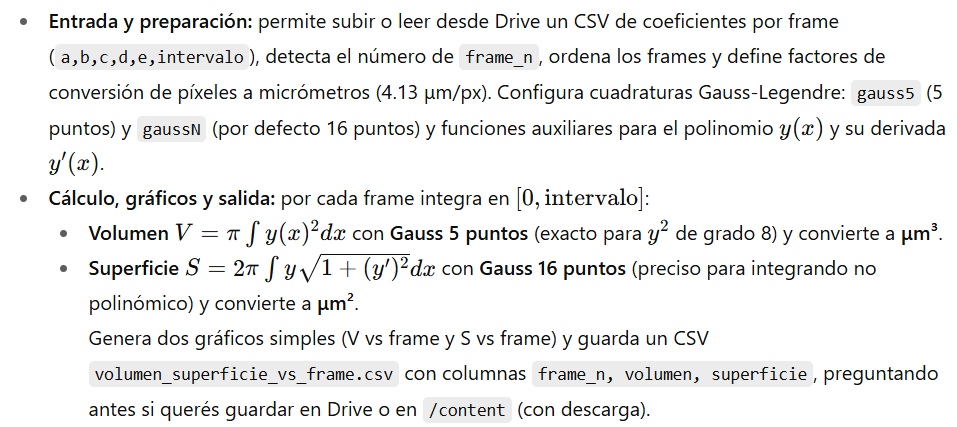

In [ ]:
# =======================
# Volumen y Superficie por frame (unidades físicas) desde coeficientes grado 4
# - Lee: coeficientes_ajuste_*.csv con columnas a,b,c,d,e,intervalo (+ opcional frame)
# - V = π ∫ y(x)^2 dx      (Gauss 5 ptos -> exacto)
# - S = 2π ∫ y sqrt(1+y'^2) dx  (Gauss n=16 -> muy preciso)
# - Salida CSV: frame_n, volumen, superficie  (volumen en μm^3, superficie en μm^2)
# - Extra: error_superficie_rel_pct = 100*|S32 - S16|/|S32|
# - Gráficas simples: V vs frame, S vs frame
# =======================
import os, re, math, numpy as np, pandas as pd
import plotly.graph_objects as go
from google.colab import output
output.enable_custom_widget_manager()

# ---------- Parámetros ----------
X_LOWER = 0.0               # límite inferior de integración
ESCALA_UM_POR_PX = 4.13     # μm/px
N_GAUSS_SURF = 16           # puntos Gauss-Legendre para superficie (no polinómico)
N_GAUSS_SURF_REF = 32       # referencia más fina para estimar error relativo de superficie

# Conversión de unidades:
PX_TO_UM   = ESCALA_UM_POR_PX
PX2_TO_UM2 = (ESCALA_UM_POR_PX**2)
PX3_TO_UM3 = (ESCALA_UM_POR_PX**3)

# ---------- I/O (Colab/Drive) ----------
def elegir_csv(default_dir="/content/drive/MyDrive/Procesados/Contornos separados/",
               nombre_base=None):
    eleccion = input("¿Cargar archivo? 1 = subir CSV, 0 = usar Drive: ").strip()
    if eleccion == '1':
        from google.colab import files
        print("Elegí el CSV de coeficientes (coeficientes_ajuste_izq/der.csv)")
        up = files.upload()
        assert len(up) == 1, "Subí exactamente un archivo CSV."
        return list(up.keys())[0], True
    else:
        from google.colab import drive
        drive.mount('/content/drive')
        base_dir = default_dir
        if not nombre_base:
            nombre_base = input("Nombre del CSV en Drive (ej: coeficientes_ajuste_izq.csv): ").strip()
        return os.path.join(base_dir, nombre_base), False

def guardar_salida_df(df, suggested_name, src_path, is_local_upload):
    """
    - Si el archivo fue subido localmente: guarda en /content y descarga.
    - Si se eligió Drive: PREGUNTA si querés guardar en Drive (s/n).
        * s -> guarda junto al CSV origen (en Drive).
        * n -> guarda en /content y descarga.
    """
    if is_local_upload:
        out_dir = "/content"
    else:
        ans = input("Guardar archivo en Drive junto al CSV origen? (s/n): ").strip().lower()
        if ans == 's':
            out_dir = os.path.dirname(os.path.abspath(src_path))
        else:
            out_dir = "/content"

    out_path = os.path.join(out_dir, suggested_name)
    df.to_csv(out_path, index=False)
    print(f"Archivo guardado en: {out_path}")

    if (is_local_upload) or (out_dir == "/content"):
        try:
            from google.colab import files as gfiles
            gfiles.download(out_path)
            print("Descargando a tu computadora…")
        except Exception as e:
            print(f"No pude iniciar la descarga: {e}\nBajalo manualmente desde el panel (ruta /content).")
    return out_path

# ---------- Polinomio grado 4 y derivada ----------
def poly4_coeffs(row, colmap):
    a = float(row[colmap["a"]]); b = float(row[colmap["b"]]); c = float(row[colmap["c"]])
    d = float(row[colmap["d"]]); e = float(row[colmap["e"]])
    return a,b,c,d,e

def y_poly(a,b,c,d,e):
    # y = a x^4 + b x^3 + c x^2 + d x + e
    return lambda x: (((a*x + b)*x + c)*x + d)*x + e

def dy_poly(a,b,c,d,e):
    # y' = 4 a x^3 + 3 b x^2 + 2 c x + d
    return lambda x: (4*a*x + 3*b)*x*x + 2*c*x + d

# ---------- Gauss-Legendre genérico ----------
def gauss_legendre(f, a, b, n):
    # usa nodos/pesos de numpy para n puntos en [-1,1]
    xi, wi = np.polynomial.legendre.leggauss(n)
    c = 0.5*(a+b); h = 0.5*(b-a)
    xx = c + h*xi
    return h * np.sum(wi * f(xx))

# Versiones específicas:
def gauss5(f, a, b):   # exacto hasta grado 9 (sirve para y^2, grado 8)
    return gauss_legendre(f, a, b, 5)

def gaussN(f, a, b, n=N_GAUSS_SURF):
    return gauss_legendre(f, a, b, n)

# ---------- Frame numérico ----------
def frame_index_from_name(name, fallback):
    m = re.search(r"(\d+)$", str(name))
    return int(m.group(1)) if m else int(fallback)

# ===================== Carga =====================
CSV_PATH, IS_LOCAL_UPLOAD = elegir_csv()
coef = pd.read_csv(CSV_PATH)

# map case-insensitive
colmap = {c.lower(): c for c in coef.columns}
for k in ["a","b","c","d","e","intervalo"]:
    assert k in colmap, f"Falta columna '{k}'"

# ordenar y definir frame_n
if "frame" in colmap:
    coef["frame_n"] = [frame_index_from_name(v, i) for i, v in enumerate(coef[colmap["frame"]].values)]
else:
    coef["frame_n"] = np.arange(len(coef))
coef = coef.sort_values("frame_n").reset_index(drop=True)

# ===================== Cálculo =====================
vol_um3 = []
surf_um2 = []
surf_err_pct = []   # <<--- NUEVO: error relativo porcentual de superficie (Gauss16 vs Gauss32)

for _, row in coef.iterrows():
    a,b,c,d,e = poly4_coeffs(row, colmap)
    xU = float(row[colmap["intervalo"]])

    if not np.isfinite(xU) or xU <= X_LOWER:
        vol_um3.append(np.nan); surf_um2.append(np.nan); surf_err_pct.append(np.nan); continue

    y  = y_poly(a,b,c,d,e)
    dy = dy_poly(a,b,c,d,e)

    # --- Volumen (px^3) ---
    fV = lambda x: (y(x)**2)              # integrando para volumen sin π
    V_px3 = math.pi * gauss5(fV, X_LOWER, xU)  # π ∫ y^2 dx  (exacto)
    V_um3 = V_px3 * PX3_TO_UM3

    # --- Superficie (px^2) ---
    fS = lambda x: y(x) * np.sqrt(1.0 + (dy(x)**2))
    # Gauss 16 (tu valor "oficial")
    S_px2_16 = 2.0 * math.pi * gauss_legendre(fS, X_LOWER, xU, 16)
    # Gauss 32 (referencia para estimar el error relativo)
    S_px2_32 = 2.0 * math.pi * gauss_legendre(fS, X_LOWER, xU, N_GAUSS_SURF_REF)

    # Resultado final (como antes: el de 16 pts)
    S_um2 = S_px2_16 * PX2_TO_UM2

    # Error relativo porcentual (independiente de unidades)
    if np.isfinite(S_px2_32) and S_px2_32 != 0.0:
        err_surf_pct = 100.0 * abs(S_px2_32 - S_px2_16) / abs(S_px2_32)
    else:
        err_surf_pct = np.nan

    vol_um3.append(float(V_um3))
    surf_um2.append(float(S_um2))
    surf_err_pct.append(float(err_surf_pct))

out = pd.DataFrame({
    "frame_n": coef["frame_n"].astype(int),
    "volumen": vol_um3,                      # [μm^3]
    "superficie": surf_um2,                  # [μm^2]
    "error_superficie_rel_pct": surf_err_pct # [%] relativo a Gauss 32
})

# ===================== Gráficas rápidas =====================
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=out["frame_n"], y=out["volumen"], mode="lines+markers", name="Volumen"))
fig1.update_layout(title="Volumen vs frame [μm³]", xaxis_title="frame_n", yaxis_title="volumen [μm³]",
                   height=380, width=900)
fig1.show()

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=out["frame_n"], y=out["superficie"], mode="lines+markers", name="Superficie"))
fig2.update_layout(title="Superficie vs frame [μm²]", xaxis_title="frame_n", yaxis_title="superficie [μm²]",
                   height=380, width=900)
fig2.show()

# (Opcional) mini resumen del error relativo
if np.isfinite(out["error_superficie_rel_pct"]).any():
    print("Resumen error superficie (Gauss16 vs Gauss32) [%]: "
          f"media={np.nanmean(out['error_superficie_rel_pct']):.3e}, "
          f"máx={np.nanmax(out['error_superficie_rel_pct']):.3e}")

# ===================== Guardar (confirmación si es Drive) =====================
fname = "volumen_superficie_vs_frame.csv"
guardar_salida_df(out, fname, CSV_PATH, IS_LOCAL_UPLOAD)

print("Listo ✅  (V en μm³, S en μm²; Gauss 5pts exacto para V, Gauss 16pts preciso para S; "
      "error_superficie_rel_pct vs Gauss 32 incluido)")


## Splines grado 3 + Simpson Compuesto 1/3

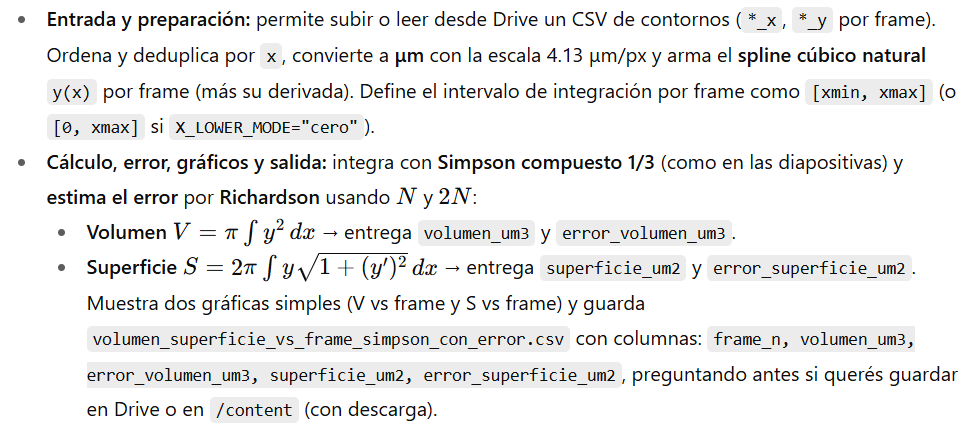

In [ ]:
# =======================
# Volumen (μm³) y Superficie (μm²) con Splines Cúbicos + Simpson compuesto (1/3)
# + Estimación de error por Richardson (|I_{2N}-I_N|/15)
# =======================
import os, re, math, numpy as np, pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import CubicSpline
from google.colab import output
output.enable_custom_widget_manager()



# ---------- Parámetros editables ----------
ESCALA_UM_POR_PX = 4.13     # μm/px
N_SIMPSON = 400             # subintervalos base (PAR). El error usa también 2*N
X_LOWER_MODE = "xmin"       # "xmin" para integrar [xmin, xmax] | "cero" para [0, xmax]

# ---------- Conversión de unidades ----------
PX_TO_UM   = ESCALA_UM_POR_PX
PX2_TO_UM2 = ESCALA_UM_POR_PX**2
PX3_TO_UM3 = ESCALA_UM_POR_PX**3

# ===== Filtro de meseta (copiado del otro código) =====
# Parámetros del filtro (podés dejarlos iguales)
FLOOR_FROM = 17     # aplicar filtro a partir de este frame (número en el nombre)
SLOPE_TOL  = 1e-3   # |pendiente| ~ 0 considerada meseta
MIN_RUN    = 12     # longitud mínima de corrida plana para eliminar
KEEP_FIRST = 1      # cuántos puntos iniciales de la meseta conservar

def _frame_number_from_name(name, fallback):
    m = re.search(r"(\d+)$", str(name))
    return int(m.group(1)) if m else int(fallback)

def sort_and_dedup_x(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    if x.size == 0: return x, y
    idx = np.argsort(x); x, y = x[idx], y[idx]
    xu = np.unique(x)
    y_means = np.array([float(np.mean(y[x==xv])) for xv in xu])
    return xu, y_means

def drop_flat_runs_by_slope(x, y, slope_tol=SLOPE_TOL, min_run=MIN_RUN, keep_first=KEEP_FIRST):
    x = np.asarray(x, float); y = np.asarray(y, float)
    if x.size < 3: return x, y
    idx = np.argsort(x); x, y = x[idx], y[idx]
    dx = np.diff(x); dy = np.diff(y)
    slope = np.zeros_like(x)
    with np.errstate(divide='ignore', invalid='ignore'):
        slope[1:-1] = (y[2:] - y[:-2]) / (x[2:] - x[:-2])
        slope[0]    = dy[0] / (dx[0] if dx[0]!=0 else 1e-12)
        slope[-1]   = dy[-1] / (dx[-1] if dx[-1]!=0 else 1e-12)
    flat = np.isfinite(slope) & (np.abs(slope) <= slope_tol)
    keep = np.ones_like(x, bool)
    i, n = 0, len(x)
    while i < n:
        if flat[i]:
            j = i + 1
            while j < n and flat[j]: j += 1
            if (j - i) >= min_run:
                drop_start = i + max(keep_first, 0)
                keep[drop_start:j] = False
            i = j
        else:
            i += 1
    return x[keep], y[keep]

def remove_local_outliers(x, y, win=5, n_sigma=3.0):
    x = np.asarray(x, float); y = np.asarray(y, float)
    n = len(y)
    if n == 0 or win < 3: return x, y
    if win % 2 == 0: win += 1
    half = win // 2
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        i0 = max(0, i - half); i1 = min(n, i + half + 1)
        yloc = y[i0:i1]
        med = np.median(yloc)
        mad = np.median(np.abs(yloc - med)) + 1e-9
        if np.abs(y[i] - med) > n_sigma * 1.4826 * mad:
            keep[i] = False
    return x[keep], y[keep]

def get_clean_xy_arrays(x_arr, y_arr, frame_name, idx_in_list):
    """
    Replica get_clean_xy(...) del otro código pero a partir de arrays.
    1) Ordena por x
    2) Si el frame >= FLOOR_FROM, elimina corridas planas ("meseta")
    3) Deduplica x promediando y
    4) Saca outliers locales
    Devuelve x_clean, y_clean (en las mismas unidades de entrada).
    """
    x0 = np.asarray(x_arr, float); y0 = np.asarray(y_arr, float)
    if x0.size == 0: return x0, y0

    idx = np.argsort(x0); x_sorted, y_sorted = x0[idx], y0[idx]
    fnum = _frame_number_from_name(frame_name, idx_in_list + 1)

    if fnum >= FLOOR_FROM:
        xf, yf = drop_flat_runs_by_slope(x_sorted, y_sorted,
                                         slope_tol=SLOPE_TOL,
                                         min_run=MIN_RUN,
                                         keep_first=KEEP_FIRST)
        if len(xf) >= max(10, KEEP_FIRST + 5):
            x_sorted, y_sorted = xf, yf

    xu, yu = sort_and_dedup_x(x_sorted, y_sorted)
    xu, yu = remove_local_outliers(xu, yu, win=5, n_sigma=3.0)
    return xu, yu
# ===== Fin filtro de meseta =====

# ---------- I/O helpers (tu patrón) ----------
def elegir_csv(default_dir="/content/drive/MyDrive/Procesados/Contornos separados/",
               nombre_base=None):
    eleccion = input("¿Cargar archivo? 1 = subir CSV, 0 = usar Drive: ").strip()
    if eleccion == '1':
        from google.colab import files
        print("Elegí el CSV de contornos (ej: contornos_izq.csv)")
        up = files.upload()
        assert len(up) == 1, "Subí exactamente un archivo CSV."
        return list(up.keys())[0], True
    else:
        from google.colab import drive
        drive.mount('/content/drive')
        base_dir = default_dir
        if not nombre_base:
            nombre_base = input("Nombre del CSV en Drive (ej: contornos_izq.csv): ").strip()
        return os.path.join(base_dir, nombre_base), False

def guardar_salida_df(df, suggested_name, src_path, is_local_upload):
    """
    - Si subiste local: guarda en /content y descarga.
    - Si elegiste Drive: pregunta (s/n) y guarda en Drive o /content (con descarga).
    """
    if is_local_upload:
        out_dir = "/content"
    else:
        ans = input("Guardar archivo en Drive junto al CSV origen? (s/n): ").strip().lower()
        out_dir = os.path.dirname(os.path.abspath(src_path)) if ans == 's' else "/content"

    out_path = os.path.join(out_dir, suggested_name)
    df.to_csv(out_path, index=False)
    print(f"Archivo guardado en: {out_path}")
    if (is_local_upload) or (out_dir == "/content"):
        try:
            from google.colab import files as gfiles
            gfiles.download(out_path)
            print("Descargando a tu computadora…")
        except Exception as e:
            print(f"No pude iniciar la descarga: {e}\nBajalo manualmente desde el panel (ruta /content).")
    return out_path

# ---------- Utilidades ----------
def _order_key(name: str):
    m = re.search(r"(\d+)$", str(name))
    return (int(m.group(1)) if m else 1_000_000, str(name))

def load_frames_contours(csv_path):
    df = pd.read_csv(csv_path, dtype=object)
    bases = []
    for c in df.columns:
        m = re.match(r"(.+)_x$", c)
        if m and f"{m.group(1)}_y" in df.columns:
            bases.append(m.group(1))
    bases = sorted(bases, key=_order_key)

    frames = []
    for b in bases:
        x = pd.to_numeric(df[f"{b}_x"], errors="coerce").to_numpy()
        y = pd.to_numeric(df[f"{b}_y"], errors="coerce").to_numpy()
        good = ~np.isnan(x) & ~np.isnan(y)
        x = x[good]; y = y[good]
        if x.size == 0:
            frames.append({"name": b, "x": np.array([]), "y": np.array([])})
            continue
        # ordenar y deduplicar por x (promediando y repetidos)
        idx = np.argsort(x); x = x[idx]; y = y[idx]
        xu = np.unique(x)
        y_means = np.array([float(np.mean(y[x==xv])) for xv in xu])
        frames.append({"name": b, "x": xu, "y": y_means})
    return frames

def frame_index_from_name(name, fallback):
    m = re.search(r"(\d+)$", str(name))
    return int(m.group(1)) if m else int(fallback)

# Simpson compuesto 1/3 (diapositivas)
def simpson_comp(f, a, b, n):
    """
    Simpson compuesto (1/3). n debe ser PAR.
    Integral ≈ (h/3)[ f(x0) + f(xn) + 4*sum f(x_odd) + 2*sum f(x_even) ].
    """
    if n % 2 != 0:
        n += 1  # por si acaso
    h = (b - a) / n
    x = a + h * np.arange(n + 1)
    fx = f(x)
    S = fx[0] + fx[-1] + 4.0 * fx[1:-1:2].sum() + 2.0 * fx[2:-1:2].sum()
    return (h / 3.0) * S

def simpson_con_error(f, a, b, n_base):
    """
    Calcula integral con Simpson usando n_base (par) y 2*n_base, y estima error:
      E ≈ |I_{2N} - I_N| / 15
    Devuelve (I_2N, E)
    """
    if n_base % 2 != 0:
        n_base += 1
    I_N   = simpson_comp(f, a, b, n_base)
    I_2N  = simpson_comp(f, a, b, 2*n_base)
    err   = abs(I_2N - I_N) / 15.0
    return I_2N, err

# ===================== Carga =====================
CSV_PATH, IS_LOCAL_UPLOAD = elegir_csv()
frames = load_frames_contours(CSV_PATH)
assert len(frames) > 0, "No se detectaron pares *_x/_y."

# ===================== Cálculo por frame =====================
rows = []
for i, fr in enumerate(frames):
    xpx = fr["x"]; ypx = fr["y"]
    fn = frame_index_from_name(fr["name"], i)

    # --- NUEVO: limpiar meseta/outliers con el pipeline probado ---
    x_clean_px, y_clean_px = get_clean_xy_arrays(xpx, ypx, fr["name"], i)
    if x_clean_px.size < 4:
        rows.append({"frame_n": fn, "volumen_um3": np.nan, "error_volumen_um3": np.nan,
                    "superficie_um2": np.nan, "error_superficie_um2": np.nan})
        continue

    # pasar a μm (slope no cambia al escalar x,y)
    x = x_clean_px * PX_TO_UM
    y = y_clean_px * PX_TO_UM

    # dominio de integración
    xmin = float(np.min(x)); xmax = float(np.max(x))
    if X_LOWER_MODE == "cero":
        a = 0.0; b = xmax
    else:
        a = xmin; b = xmax
    if not (np.isfinite(a) and np.isfinite(b)) or b <= a:
        rows.append({"frame_n": fn, "volumen_um3": np.nan, "error_volumen_um3": np.nan,
                     "superficie_um2": np.nan, "error_superficie_um2": np.nan})
        continue

    # spline cúbico natural y su derivada
    cs  = CubicSpline(x, y, bc_type='natural')
    dcs = cs.derivative(1)

    # integrandos (ya en unidades físicas)
    fV = lambda xx: (cs(xx)**2) * math.pi                          # π y^2
    fS = lambda xx: 2.0 * math.pi * cs(xx) * np.sqrt(1.0 + (dcs(xx)**2))  # 2π y sqrt(1+y'^2)

    # Simpson compuesto + error (Richardson)
    V_um3, eV_um3 = simpson_con_error(fV, a, b, N_SIMPSON)
    S_um2, eS_um2 = simpson_con_error(fS, a, b, N_SIMPSON)

    rows.append({
        "frame_n": fn,
        "volumen_um3": float(V_um3),
        "error_volumen_um3": float(eV_um3),
        "superficie_um2": float(S_um2),
        "error_superficie_um2": float(eS_um2)
    })

out = pd.DataFrame(rows).sort_values("frame_n").reset_index(drop=True)

# ===================== Gráficas simples =====================
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=out["frame_n"], y=out["volumen_um3"],
                          mode="lines+markers", name="Volumen"))
fig1.update_layout(title="Volumen vs frame [μm³]", xaxis_title="frame_n", yaxis_title="volumen [μm³]",
                   height=380, width=900)
fig1.show()

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=out["frame_n"], y=out["superficie_um2"],
                          mode="lines+markers", name="Superficie"))
fig2.update_layout(title="Superficie vs frame [μm²]", xaxis_title="frame_n", yaxis_title="superficie [μm²]",
                   height=380, width=900)
fig2.show()

# ===================== Guardar (confirmación si es Drive) =====================
fname = "volumen_superficie_vs_frame_simpson_con_error.csv"
guardar_salida_df(out, fname, CSV_PATH, IS_LOCAL_UPLOAD)
print("Listo ✅  (Simpson 1/3 + error ≈ |I_{2N}-I_N|/15; N base =", N_SIMPSON, ")")

# ===================== Masa promedio de la gota =====================
# Convertir volumen de µm³ a m³
out["volumen_m3"] = out["volumen_um3"] * 1e-18   # (1 µm = 1e-6 m → (1e-6)^3 = 1e-18)

# Densidad (kg/m³)
rho = 7380.0

# Masa por frame (kg)
out["masa_kg"] = out["volumen_m3"] * rho

# Promedio de masa sobre todos los contornos válidos
masa_promedio = out["masa_kg"].mean()

print("=== MASA DE LA GOTA ===")
print(f"Masa promedio ≈ {masa_promedio:.6e} kg")
print(f"Equivalente ≈ {masa_promedio*1e6:.3f} mg")

# Gráfico de masa por frame
import plotly.express as px
fig3 = px.line(out, x="frame_n", y="masa_kg", markers=True,
               title="Masa estimada de la gota por frame",
               labels={"frame_n":"Frame", "masa_kg":"Masa [kg]"})
fig3.show()


¿Cargar archivo? 1 = subir CSV, 0 = usar Drive: 0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Nombre del CSV en Drive (ej: contornos_izq.csv): contornos_izq.csv


Guardar archivo en Drive junto al CSV origen? (s/n): s
Archivo guardado en: /content/drive/MyDrive/Procesados/Contornos separados/volumen_superficie_vs_frame_simpson_con_error.csv
Listo ✅  (Simpson 1/3 + error ≈ |I_{2N}-I_N|/15; N base = 400 )
=== MASA DE LA GOTA ===
Masa promedio ≈ 1.097904e-07 kg
Equivalente ≈ 0.110 mg


### Grafica Splines

In [ ]:
# =======================
# Visualización interactiva del SPLINE por frame (puntos limpios vs ajuste)
# =======================
import ipywidgets as W
from IPython.display import display

def _get_xy_um_clean(i):
    """Devuelve x,y LIMPIOS (sin meseta/outliers) en μm para el frame i."""
    fr = frames[i]
    x_clean_px, y_clean_px = get_clean_xy_arrays(fr["x"], fr["y"], fr["name"], i)
    x = x_clean_px * PX_TO_UM
    y = y_clean_px * PX_TO_UM
    return x, y

def _spline_curve_for_frame(i, n_samples=400):
    x, y = _get_xy_um_clean(i)
    if x.size < 4:
        return np.array([]), np.array([]), x, y
    cs = CubicSpline(x, y, bc_type='natural')
    xmin, xmax = float(np.min(x)), float(np.max(x))
    xs = np.linspace(xmin, xmax, n_samples)
    ys = cs(xs)
    return xs, ys, x, y

# primer frame válido (con puntos limpios suficientes)
valid_idx = 0
for k in range(len(frames)):
    if _get_xy_um_clean(k)[0].size >= 4:
        valid_idx = k
        break

xs0, ys0, x0, y0 = _spline_curve_for_frame(valid_idx)

fig_sp = go.FigureWidget(
    data=[
        go.Scatter(x=x0,  y=y0,  mode="markers", name="Puntos limpios (μm)", marker=dict(size=6)),
        go.Scatter(x=xs0, y=ys0, mode="lines",   name="Spline cúbico (μm)", line=dict(width=2))
    ],
    layout=go.Layout(
        title=f"Ajuste spline – Frame {frame_index_from_name(frames[valid_idx]['name'], valid_idx)}",
        xaxis=dict(title="x [μm]"),
        yaxis=dict(title="y [μm]"),
        height=520, width=900,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        margin=dict(t=80, r=20, b=60, l=70),
        uirevision=True
    )
)

slider_sp = W.IntSlider(value=valid_idx, min=0, max=len(frames)-1, step=1,
                        description='Frame:', continuous_update=False, layout=W.Layout(width="700px"))
play_sp   = W.Play(interval=80, value=valid_idx, min=0, max=len(frames)-1, step=1, description="Play")
W.jslink((play_sp, 'value'), (slider_sp, 'value'))

dd_sp = W.Dropdown(
    options=[(f"[{frame_index_from_name(fr['name'], i)}] {fr['name']}", i) for i, fr in enumerate(frames)],
    value=valid_idx, description='Ir a:', layout=W.Layout(width="400px")
)

def _refresh_spline(i):
    xs, ys, x, y = _spline_curve_for_frame(i)
    with fig_sp.batch_update():
        fig_sp.data[0].x = x;   fig_sp.data[0].y = y
        fig_sp.data[1].x = xs;  fig_sp.data[1].y = ys
        fn = frame_index_from_name(frames[i]['name'], i)
        fig_sp.layout.title = f"Ajuste spline – Frame {fn}"

def _on_slider(change):
    if change["name"] == "value":
        dd_sp.value = change["new"]
        _refresh_spline(change["new"])

def _on_dropdown(change):
    if change["name"] == "value":
        slider_sp.value = change["new"]

slider_sp.observe(_on_slider, names="value")
dd_sp.observe(_on_dropdown, names="value")

display(W.HBox([play_sp, slider_sp]), dd_sp, fig_sp)


Dropdown(description='Ir a:', layout=Layout(width='400px'), options=(('[1] imagen1', 0), ('[2] imagen2', 1), (…

FigureWidget({
    'data': [{'marker': {'size': 6},
              'mode': 'markers',
              'name': 'Puntos limpios (μm)',
              'type': 'scatter',
              'uid': 'd35c48cb-b575-4eb5-85bb-7b325da903ba',
              'x': array([ 0.  ,  4.13,  8.26, 12.39, 20.65]),
              'y': array([ 6.195, 26.845, 45.43 , 64.015, 20.65 ])},
             {'line': {'width': 2},
              'mode': 'lines',
              'name': 'Spline cúbico (μm)',
              'type': 'scatter',
              'uid': '349a88a4-631e-4f63-83b2-774781e388b8',
              'x': array([ 0.        ,  0.05175439,  0.10350877, ..., 20.54649123, 20.59824561,
                          20.65      ]),
              'y': array([ 6.195     ,  6.46655807,  6.73810409, ..., 21.54661935, 21.09833048,
                          20.65      ])}],
    'layout': {'height': 520,
               'legend': {'orientation': 'h', 'x': 1, 'xanchor': 'right', 'y': 1.02, 'yanchor': 'bottom'},
               'margin': {

## Comparación

In [ ]:
# =======================
# Comparador de métodos: Gauss vs Simpson (con errores)
# - Entrada:
#    1) volumen_superficie_vs_frame.csv                     (Gauss: frame_n, volumen, superficie)
#    2) volumen_superficie_vs_frame_simpson_con_error.csv  (Simpson: frame_n, volumen_um3, error_volumen_um3, superficie_um2, error_superficie_um2)
# - Gráficas interactivas: Volumen y Superficie vs frame (ambos métodos) + bandas de error para Simpson
# - Salida opcional: CSV comparativo con diferencias y porcentajes (confirmación si guardar en Drive)
# =======================
import os, numpy as np, pandas as pd
import plotly.graph_objects as go
from google.colab import output
output.enable_custom_widget_manager()

# ---------- I/O helpers (mismo patrón) ----------
def elegir_archivo(prompt_nombre, default_dir="/content/drive/MyDrive/Procesados/Contornos separados/"):
    """
    Devuelve (PATH, IS_LOCAL_UPLOAD)
    """
    eleccion = input(f"{prompt_nombre} ¿Cargar archivo? 1 = subir CSV, 0 = usar Drive: ").strip()
    if eleccion == '1':
        from google.colab import files
        print("Elegí el CSV…")
        up = files.upload()
        assert len(up) == 1, "Subí exactamente un archivo CSV."
        return list(up.keys())[0], True
    else:
        from google.colab import drive
        drive.mount('/content/drive')
        nombre = input("Nombre del CSV en Drive (ej: volumen_superficie_vs_frame.csv): ").strip()
        return os.path.join(default_dir, nombre), False

def guardar_salida_df(df, suggested_name, src_path_drive_like, is_local_any):
    """
    - Si alguno fue subido localmente: guarda en /content y descarga.
    - Si ambos fueron desde Drive: pregunta (s/n) y guarda en Drive o /content (con descarga).
    """
    # Si hubo al menos una carga local, guardamos en /content
    if is_local_any:
        out_dir = "/content"
    else:
        ans = input("Guardar archivo comparativo en Drive? (s/n): ").strip().lower()
        out_dir = os.path.dirname(os.path.abspath(src_path_drive_like)) if ans == 's' else "/content"

    out_path = os.path.join(out_dir, suggested_name)
    df.to_csv(out_path, index=False)
    print(f"Archivo guardado en: {out_path}")
    if out_dir == "/content":
        try:
            from google.colab import files as gfiles
            gfiles.download(out_path)
            print("Descargando a tu computadora…")
        except Exception as e:
            print(f"No pude iniciar la descarga: {e}\nBajalo manualmente desde el panel (ruta /content).")
    return out_path

# ---------- Carga de los dos archivos ----------
PATH_GAUSS, IS_LOCAL_G = elegir_archivo("Archivo 1 (Gauss)")
PATH_SIMP,  IS_LOCAL_S = elegir_archivo("Archivo 2 (Simpson)")

gauss = pd.read_csv(PATH_GAUSS)
simp  = pd.read_csv(PATH_SIMP)

# ---------- Normalización de nombres ----------
# Gauss: frame_n, volumen, superficie  (μm³, μm²)
gauss = gauss.rename(columns={c: c.strip() for c in gauss.columns})
simp  = simp.rename(columns={c: c.strip() for c in simp.columns})

assert "frame_n" in gauss.columns and "volumen" in gauss.columns and "superficie" in gauss.columns, \
       "El CSV Gauss debe tener columnas: frame_n, volumen, superficie"

# Simpson: frame_n, volumen_um3, error_volumen_um3, superficie_um2, error_superficie_um2
need_s = {"frame_n","volumen_um3","error_volumen_um3","superficie_um2","error_superficie_um2"}
missing = need_s - set(simp.columns)
assert not missing, f"Faltan columnas en el CSV Simpson: {missing}"

# ---------- Merge por frame_n ----------
cmp = pd.merge(
    gauss[["frame_n","volumen","superficie"]],
    simp[["frame_n","volumen_um3","error_volumen_um3","superficie_um2","error_superficie_um2"]],
    on="frame_n", how="inner"
).sort_values("frame_n").reset_index(drop=True)

# ---------- Métricas de diferencia ----------
cmp["diff_vol_um3"]      = cmp["volumen_um3"] - cmp["volumen"]             # Simpson - Gauss
cmp["diff_vol_rel_pct"]  = 100.0 * cmp["diff_vol_um3"] / np.where(cmp["volumen"]!=0, cmp["volumen"], np.nan)
cmp["diff_surf_um2"]     = cmp["superficie_um2"] - cmp["superficie"]
cmp["diff_surf_rel_pct"] = 100.0 * cmp["diff_surf_um2"] / np.where(cmp["superficie"]!=0, cmp["superficie"], np.nan)

# ---------- Gráficas interactivas ----------
# 1) Volumen: ambas curvas + banda de error (Simpson ± error)
figV = go.Figure()

figV.add_trace(go.Scatter(
    x=cmp["frame_n"], y=cmp["volumen"], mode="lines+markers",
    name="Volumen (Gauss)", hovertemplate="frame=%{x}<br>V=%{y:.3e} μm³<extra></extra>"
))
figV.add_trace(go.Scatter(
    x=cmp["frame_n"], y=cmp["volumen_um3"], mode="lines+markers",
    name="Volumen (Simpson)", hovertemplate="frame=%{x}<br>V=%{y:.3e} μm³<extra></extra>"
))
# banda de error para Simpson
y_upper = cmp["volumen_um3"] + cmp["error_volumen_um3"]
y_lower = cmp["volumen_um3"] - cmp["error_volumen_um3"]
figV.add_trace(go.Scatter(
    x=pd.concat([cmp["frame_n"], cmp["frame_n"][::-1]]),
    y=pd.concat([y_upper, y_lower[::-1]]),
    fill="toself", fillcolor="rgba(0,0,0,0.08)", line=dict(width=0),
    hoverinfo="skip", name="± error Simpson"
))
figV.update_layout(
    title="Volumen vs frame (μm³)",
    xaxis_title="frame_n", yaxis_title="Volumen [μm³]",
    height=420, width=980, legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
figV.show()

# 2) Superficie: ambas curvas + banda de error (Simpson ± error)
figS = go.Figure()
figS.add_trace(go.Scatter(
    x=cmp["frame_n"], y=cmp["superficie"], mode="lines+markers",
    name="Superficie (Gauss)", hovertemplate="frame=%{x}<br>S=%{y:.3e} μm²<extra></extra>"
))
figS.add_trace(go.Scatter(
    x=cmp["frame_n"], y=cmp["superficie_um2"], mode="lines+markers",
    name="Superficie (Simpson)", hovertemplate="frame=%{x}<br>S=%{y:.3e} μm²<extra></extra>"
))
yU = cmp["superficie_um2"] + cmp["error_superficie_um2"]
yL = cmp["superficie_um2"] - cmp["error_superficie_um2"]
figS.add_trace(go.Scatter(
    x=pd.concat([cmp["frame_n"], cmp["frame_n"][::-1]]),
    y=pd.concat([yU, yL[::-1]]),
    fill="toself", fillcolor="rgba(0,0,0,0.08)", line=dict(width=0),
    hoverinfo="skip", name="± error Simpson"
))
figS.update_layout(
    title="Superficie vs frame (μm²)",
    xaxis_title="frame_n", yaxis_title="Superficie [μm²]",
    height=420, width=980, legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
figS.show()

# 3) Diferencias relativas (%): Volumen y Superficie (Simpson - Gauss)
figDV = go.Figure()
figDV.add_trace(go.Scatter(
    x=cmp["frame_n"], y=cmp["diff_vol_rel_pct"], mode="lines+markers",
    name="ΔV% (Simpson - Gauss)", hovertemplate="frame=%{x}<br>ΔV=%{y:.3f}%<extra></extra>"
))
figDV.update_layout(
    title="Diferencia relativa de Volumen [%]",
    xaxis_title="frame_n", yaxis_title="ΔV [%]",
    height=360, width=980
)
figDV.show()

figDS = go.Figure()
figDS.add_trace(go.Scatter(
    x=cmp["frame_n"], y=cmp["diff_surf_rel_pct"], mode="lines+markers",
    name="ΔS% (Simpson - Gauss)", hovertemplate="frame=%{x}<br>ΔS=%{y:.3f}%<extra></extra>"
))
figDS.update_layout(
    title="Diferencia relativa de Superficie [%]",
    xaxis_title="frame_n", yaxis_title="ΔS [%]",
    height=360, width=980
)
figDS.show()

# ---------- Estadísticos del error ----------
def resumen_error(df, diff_abs, diff_rel, label):
    """
    Calcula métricas de error típicas y devuelve un DataFrame de resumen.
    """
    data = df[[diff_abs, diff_rel]].dropna()
    abs_vals = data[diff_abs].values
    rel_vals = data[diff_rel].values

    stats = {
        "Mínimo abs": np.nanmin(abs_vals),
        "Máximo abs": np.nanmax(abs_vals),
        "Promedio abs": np.nanmean(abs_vals),
        "Desvío estándar abs": np.nanstd(abs_vals),
        "Mínimo rel (%)": np.nanmin(rel_vals),
        "Máximo rel (%)": np.nanmax(rel_vals),
        "Promedio rel (%)": np.nanmean(rel_vals),
        "Desvío estándar rel (%)": np.nanstd(rel_vals),
        "Error medio absoluto (MAE, %)": np.nanmean(np.abs(rel_vals)),
        "Error cuadrático medio (RMSE, %)": np.sqrt(np.nanmean(rel_vals**2)),
    }
    out = pd.DataFrame(list(stats.items()), columns=["Métrica", label])
    return out

# Calcular ambos resúmenes
res_vol = resumen_error(cmp, "diff_vol_um3", "diff_vol_rel_pct", "Volumen")
res_surf = resumen_error(cmp, "diff_surf_um2", "diff_surf_rel_pct", "Superficie")

# Unir lado a lado
resumen = pd.concat([res_vol, res_surf["Superficie"]], axis=1)
print("\n==================== ESTADÍSTICOS DEL ERROR ====================")
print(resumen.to_string(index=False, justify="left", col_space=20))
print("===============================================================\n")

# Mostrar también promedio y RMSE en una vista rápida
mean_vol = np.nanmean(cmp["diff_vol_rel_pct"])
rmse_vol = np.sqrt(np.nanmean(cmp["diff_vol_rel_pct"]**2))
mean_surf = np.nanmean(cmp["diff_surf_rel_pct"])
rmse_surf = np.sqrt(np.nanmean(cmp["diff_surf_rel_pct"]**2))

print(f"Resumen rápido:")
print(f" - Volumen:  media = {mean_vol:.4f} %,  RMSE = {rmse_vol:.4f} %")
print(f" - Superficie: media = {mean_surf:.4f} %,  RMSE = {rmse_surf:.4f} %")


# ---------- Guardado comparativo (opcional) ----------
guardar = input("¿Guardar CSV comparativo (s/n)? ").strip().lower()
if guardar == 's':
    cols_out = [
        "frame_n",
        "volumen", "volumen_um3", "error_volumen_um3", "diff_vol_um3", "diff_vol_rel_pct",
        "superficie", "superficie_um2", "error_superficie_um2", "diff_surf_um2", "diff_surf_rel_pct"
    ]
    # Si ambos vinieron de Drive, usamos el path del primero para decidir carpeta cuando sea 's'
    _ = guardar_salida_df(cmp[cols_out], "comparacion_gauss_vs_simpson.csv", PATH_GAUSS, (IS_LOCAL_G or IS_LOCAL_S))

print("Listo ✅  (Comparación Gauss vs Simpson con bandas de error y CSV opcional)")


Archivo 1 (Gauss) ¿Cargar archivo? 1 = subir CSV, 0 = usar Drive: 1
Elegí el CSV…


Saving volumen_superficie_vs_frame.csv to volumen_superficie_vs_frame (1).csv
Archivo 2 (Simpson) ¿Cargar archivo? 1 = subir CSV, 0 = usar Drive: 1
Elegí el CSV…


Saving volumen_superficie_vs_frame_simpson_con_error.csv to volumen_superficie_vs_frame_simpson_con_error (2).csv



==================== ESTADÍSTICOS DEL ERROR ====================
Métrica                           Volumen              Superficie         
                      Mínimo abs -1.438365e+06        -46139.105259       
                      Máximo abs  3.291461e+05         17413.887145       
                    Promedio abs -2.150118e+05          5287.738621       
             Desvío estándar abs  3.074536e+05         11084.819595       
                  Mínimo rel (%) -9.296525e+00           -15.881246       
                  Máximo rel (%)  2.112720e+00             8.562336       
                Promedio rel (%) -1.382396e+00             1.885020       
         Desvío estándar rel (%)  2.000773e+00             3.932136       
   Error medio absoluto (MAE, %)  1.667047e+00             3.805836       
Error cuadrático medio (RMSE, %)  2.431894e+00             4.360618       

Resumen rápido:
 - Volumen:  media = -1.3824 %,  RMSE = 2.4319 %
 - Superficie: media = 1.8850 %,  RMSE = 4.